Generating avatar template...
Loaded mesh from models/smplx/smplx_uv.obj, with 10475 vertices and 20908 faces.
Generated and saved avatar template to: models/avatar_template.ply
Loaded mesh from models/smplx/smplx_uv.obj, with 10475 vertices and 20908 faces.
Loaded avatar template from: models/avatar_template.ply
Statistics for scales[:, 0]:
  count   : 83632
  mean    : 0.002114
  std     : 0.001746
  median  : 0.001570
  min/max : 0.000077 / 0.008485
  q25/q75 : 0.000522 / 0.003453


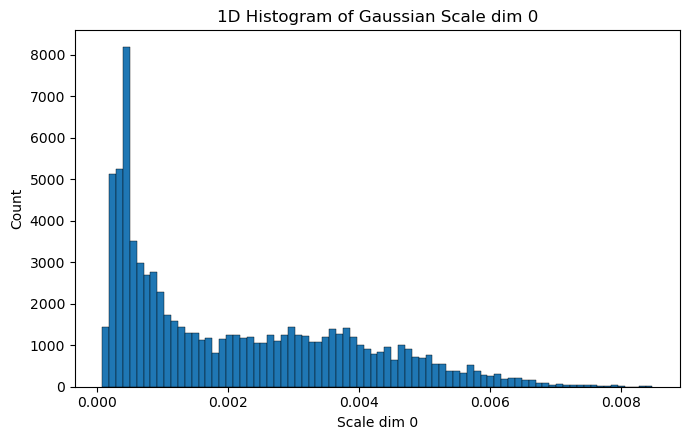

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure project imports work in notebook kernels
PROJECT_ROOT = Path.cwd()
SRC_ROOT = PROJECT_ROOT / "src"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from src.encoder.avatar_template import AvatarTemplate

# avatar_template can be an in-memory object or a file path
template_obj = AvatarTemplate().load_avatar_template(mode="default")

def extract_scales(obj):
    # dict-style candidates
    if isinstance(obj, dict):
        for k in ["scales", "scale", "_scaling"]:
            if k in obj:
                return obj[k]
        if "gaussians" in obj:
            return extract_scales(obj["gaussians"])

    # attribute-style candidates
    for attr in ["scales", "scale", "_scaling"]:
        if hasattr(obj, attr):
            return getattr(obj, attr)

    if hasattr(obj, "gaussians"):
        return extract_scales(obj.gaussians)

    raise ValueError("Cannot find Gaussian scales in avatar_template.")

scales = extract_scales(template_obj)
if isinstance(scales, torch.Tensor):
    scales = scales.detach().cpu().numpy()
else:
    scales = np.asarray(scales)

# Ensure shape [N, C]
scales = scales.reshape(scales.shape[0], -1)
if scales.shape[1] < 1:
    raise ValueError(f"Need at least 1 scale channel for 1D histogram, got shape {scales.shape}.")

scale_0 = scales[:, 0]

print("Statistics for scales[:, 0]:")
print(f"  count   : {scale_0.size}")
print(f"  mean    : {scale_0.mean():.6f}")
print(f"  std     : {scale_0.std():.6f}")
print(f"  median  : {np.median(scale_0):.6f}")
print(f"  min/max : {scale_0.min():.6f} / {scale_0.max():.6f}")
q25, q75 = np.quantile(scale_0, [0.25, 0.75])
print(f"  q25/q75 : {q25:.6f} / {q75:.6f}")

# 1D histogram for scales[:, 0]
plt.figure(figsize=(7, 4.5))
plt.hist(scale_0, bins=80, edgecolor="black", linewidth=0.3)
plt.xlabel("Scale dim 0")
plt.ylabel("Count")
plt.title("1D Histogram of Gaussian Scale dim 0")
plt.tight_layout()
plt.show()